I used Gemini with the guided learning enabled to help me with understanding, and walking me through the steps to solve everything while asking questions of me and I of it.


# Ex6.1

$\mathbb{E}(C_0) = \frac{1*4+0*3+0*5}{12} = \frac{4}{12}$

$\mathbb{E}(C_1) = \frac{0*4+1*3+0*5}{12} = \frac{3}{12}$



$\mathbb{E}(Y| X = 0) = \frac{1*2+0*0+0*4}{6} = \frac{2}{6}$

$\mathbb{E}(Y| X = 1) = \frac{0*2+1*3+0*1}{6} = \frac{3}{6}$


Avg treatment effect:

$$\theta = \mathbb{E}(C_1) - \mathbb{E}(C_0)$$

$$= \frac{3}{12} - \frac{4}{12} = -\frac{1}{12}$$


Association:

$$\alpha = \mathbb{E}(Y| X = 1) - \mathbb{E}(Y| X = 0)$$

$$= \frac{3}{6} - \frac{2}{6} = \frac{1}{6}$$

# Ex6.2


    Y=1   Y=0
X=1|15+20|25+m
X=0|5+20|10+10

    Y=1 Y=0
X=1|35|25+m
X=0|25|20


\begin{aligned}
    &\begin{array}{c|c|c|}
        Z=1  & Y=1 & Y=0  \\
        \hline \hline
        X=1 & 15 & 25 \\
        \hline
        X=0 & 5 & 10 \\
        \hline
    \end{array}
    &\begin{array}{c|c|c|}
        Z=0 & Y=1 & Y=0  \\
        \hline \hline
        X=1 & 20 & m \\
        \hline
        X=0 & 20 & 10 \\
        \hline
    \end{array}
\end{aligned}



\begin{aligned}
    &\begin{array}{c|c|c|}
        Z  & Y=1 & Y=0  \\
        \hline \hline
        X=1 & 35 & 25+m & 60+m \\
        \hline
        X=0 & 25 & 20 & 45 \\
        \hline \hline
         & 60 & 45+m
    \end{array}
\end{aligned}


---


$$P(Y=1 | X=1) - P(Y=1 | X=0)$$

$$= \frac{P(Y=1, X=1)}{P(X=1)} - \frac{P(Y=1, X=0)}{P(X=0)}$$

$$= \frac{35}{60+m} - \frac{25}{45}$$

m >= 4 negative results for whole group

---


$$P(Y=1 | X=1, Z=1) - P(Y=1 | X=0, Z=1)$$

$$= \frac{P(Y=1, X=1, Z=1)}{P(X=1, Z=1)} - \frac{P(Y=1, X=0, Z=1)}{P(X=0, Z=1)}$$

$$= \frac{15}{40} - \frac{5}{15}$$

$$= \frac{45}{120} - \frac{40}{120} $$

$$= \frac{5}{120} = \frac{1}{24} =  0.0417$$

---


$$P(Y=1 | X=1, Z=0) - P(Y=1 | X=0, Z=0)$$

$$= \frac{P(Y=1, X=1, Z=0)}{P(X=1, Z=0)} - \frac{P(Y=1, X=0, Z=0)}{P(X=0, Z=0)}$$

$$= \frac{20}{20+m} - \frac{20}{30}$$

m < 10 positive results

---


$$4 <= m <= 9$$


# Ex6.3

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
toys = pd.read_csv("toys.txt", sep='\t')

toys

,Full,MCAR,MAR,MNAR
0,-2.302,-0.831,NaN,NaN
1,1.091,1.272,0.205,1.419
2,-0.277,-0.116,-0.210,0.458
3,0.466,NaN,0.324,-0.559
4,0.020,1.013,-0.270,NaN
...,...,...,...,...
495,-0.658,NaN,NaN,-0.138
496,0.649,NaN,0.716,0.493
497,-0.157,-0.182,NaN,0.434
498,-1.772,-1.442,NaN,NaN


In [7]:
mean_full = np.mean(toys["Full"])
mean_mcar = np.mean(toys["MCAR"])
mean_mar = np.mean(toys["MAR"])
mean_mnar = np.mean(toys["MNAR"])

mean_full, mean_mcar, mean_mar, mean_mnar

(np.float64(-0.037666),
 np.float64(-0.07960843373493975),
 np.float64(0.3885646687697161),
 np.float64(0.436472891566265))

- The mean changes as the variable changes, growing from $X_1 to X_4$

## 2.

In [9]:
toys_present = toys.dropna()
toys_present

,Full,MCAR,MAR,MNAR
1,1.091,1.272,0.205,1.419
2,-0.277,-0.116,-0.210,0.458
5,0.449,0.117,0.473,1.134
8,-0.384,-0.612,-0.179,-0.066
14,-0.404,-0.767,-0.558,0.039
...,...,...,...,...
479,0.616,0.723,1.130,-0.722
486,0.250,0.398,-0.820,0.376
487,1.209,2.186,2.331,0.866
493,-0.519,-0.360,-1.026,-0.796


In [10]:
mean_full = np.mean(toys_present["Full"])
mean_mcar = np.mean(toys_present["MCAR"])
mean_mar = np.mean(toys_present["MAR"])
mean_mnar = np.mean(toys_present["MNAR"])

mean_full, mean_mcar, mean_mar, mean_mnar

(np.float64(0.5573614457831325),
 np.float64(0.45115662650602406),
 np.float64(0.4748975903614458),
 np.float64(0.5823373493975903))

- The means have evened out a lot, with $+- 0.1$ difference

## 3.

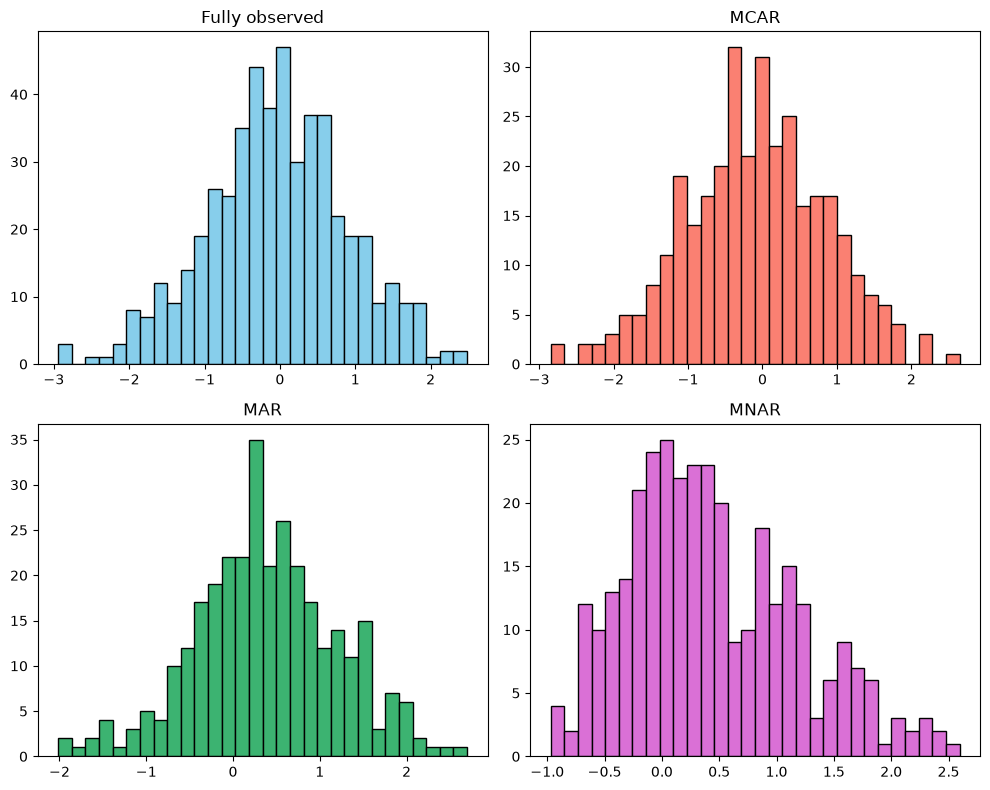

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


axes[0, 0].hist(toys["Full"], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Fully observed')

axes[0, 1].hist(toys["MCAR"], bins=30, color='salmon', edgecolor='black')
axes[0, 1].set_title('MCAR')

axes[1, 0].hist(toys["MAR"], bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('MAR')

axes[1, 1].hist(toys["MNAR"], bins=30, color='orchid', edgecolor='black')
axes[1, 1].set_title('MNAR')

plt.tight_layout()
plt.show()

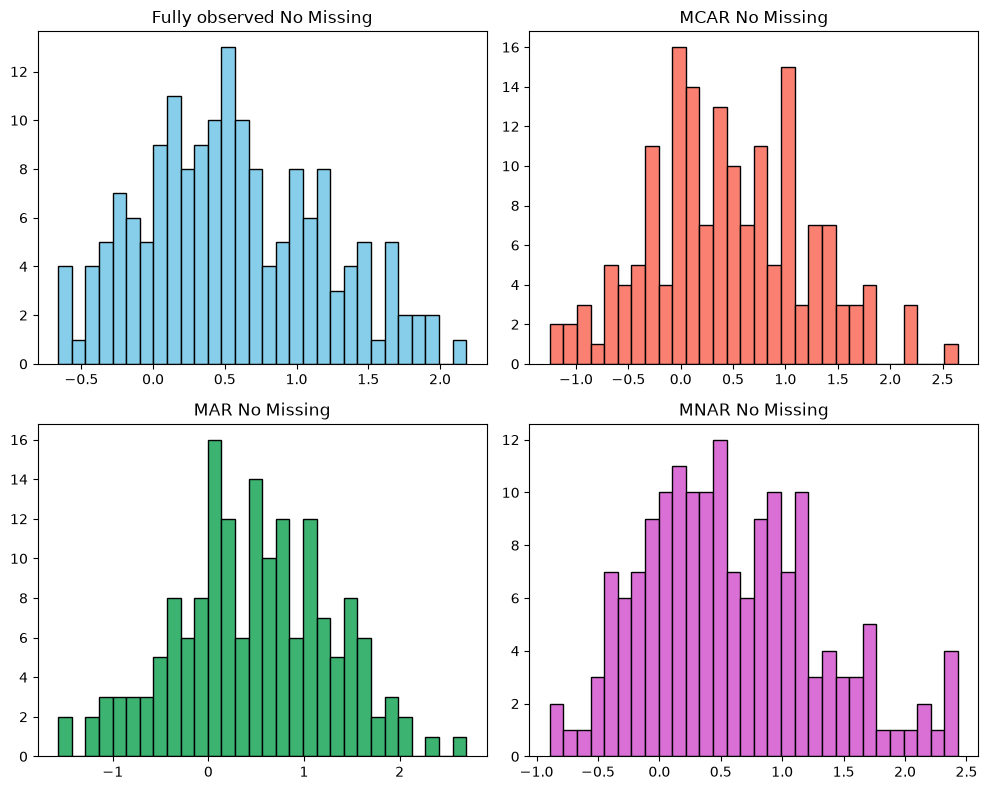

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


axes[0, 0].hist(toys_present["Full"], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Fully observed No Missing')

axes[0, 1].hist(toys_present["MCAR"], bins=30, color='salmon', edgecolor='black')
axes[0, 1].set_title('MCAR No Missing')

axes[1, 0].hist(toys_present["MAR"], bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('MAR No Missing')

axes[1, 1].hist(toys_present["MNAR"], bins=30, color='orchid', edgecolor='black')
axes[1, 1].set_title('MNAR No Missing')

plt.tight_layout()
plt.show()

- The missing values appear to help maintain an appearance of normal distribution shape for most except MNAR, which seems to get slightly more normal looking only if the missing values are ignored.
- All except MNAR seem to shift to the left a bit. Namely the X-axis' 0 shifts to the left
- Y-axis shrinks most drastically for the fully observed (from 40+ down to a bit over 12)
- 